# Day 3 — Analisis Penjualan Supermarket

Pada proyek ini kita berperan sebagai **analis data ritel**. Kita akan menganalisis
data transaksi penjualan sayuran sebuah supermarket di China untuk menemukan **tren penjualan**,
**produk terlaris**, dan **pengaruh diskon**.

> 🎯 **Tujuan Pembelajaran**
> - Mengubah kolom teks tanggal menjadi tipe **datetime** (`pd.to_datetime`).
> - Bekerja dengan dataset **besar** (878.000+ baris) memakai **sampel** agar ringan.
> - Melakukan agregasi dengan `groupby` & `resample`.
> - Menghitung estimasi nilai penjualan (kuantitas × harga).
> - Memvisualisasikan tren harian, produk teratas, dan sebaran harga.

**Tingkat:** Pemula–Menengah • **Estimasi waktu:** 35–45 menit

## 📊 Tentang Dataset

Dataset berisi catatan transaksi penjualan sayuran (per detail penjualan) sebuah supermarket.
File utama (`annex2.csv`) memiliki **lebih dari 878.000 baris** — sangat besar! Karena itu kita
akan mengambil **sampel acak** agar notebook tetap cepat dijalankan.

- **Sumber:** [Kaggle — yapwh1208/supermarket-sales-data](https://www.kaggle.com/datasets/yapwh1208/supermarket-sales-data)

| Kolom | Arti |
|-------|------|
| `Date` | Tanggal transaksi |
| `Time` | Waktu transaksi |
| `Item Code` | Kode produk |
| `Quantity Sold (kilo)` | Kuantitas terjual (kg) |
| `Unit Selling Price (RMB/kg)` | Harga satuan (RMB/kg) |
| `Sale or Return` | Penjualan atau retur |
| `Discount (Yes/No)` | Apakah ada diskon |

# Import Dataset & Library

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Instal Kaggle
!pip install -q kaggle

# Pastikan file kaggle.json sudah di-upload ke Colab
# Jalankan perintah ini untuk mendownload dan unzip otomatis
!kaggle datasets download yapwh1208/supermarket-sales-data

Dataset URL: https://www.kaggle.com/datasets/yapwh1208/supermarket-sales-data
License(s): CC-BY-NC-SA-4.0
supermarket-sales-data.zip: Skipping, found more recently modified local copy (use --force to force download)


In [25]:
import zipfile

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

zip_file_path = '/content/supermarket-sales-data.zip'
csv_file_in_zip = 'annex2.csv'

with zipfile.ZipFile(zip_file_path, 'r') as zf:
    with zf.open(csv_file_in_zip) as f:
        df = pd.read_csv(f)

df.head()

,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No)
0,2020-07-01,09:15:07.924,102900005117056,0.396,7.6,sale,No
1,2020-07-01,09:17:27.295,102900005115960,0.849,3.2,sale,No
2,2020-07-01,09:17:33.905,102900005117056,0.409,7.6,sale,No
3,2020-07-01,09:19:45.450,102900005115823,0.421,10.0,sale,No
4,2020-07-01,09:20:23.686,102900005115908,0.539,8.0,sale,No


# Explorasi Awal Data menggunakan Statistic

In [26]:
print("Kolom:", list(df.columns))
df.head()

Kolom: ['Date', 'Time', 'Item Code', 'Quantity Sold (kilo)', 'Unit Selling Price (RMB/kg)', 'Sale or Return', 'Discount (Yes/No)']


,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No)
0,2020-07-01,09:15:07.924,102900005117056,0.396,7.6,sale,No
1,2020-07-01,09:17:27.295,102900005115960,0.849,3.2,sale,No
2,2020-07-01,09:17:33.905,102900005117056,0.409,7.6,sale,No
3,2020-07-01,09:19:45.450,102900005115823,0.421,10.0,sale,No
4,2020-07-01,09:20:23.686,102900005115908,0.539,8.0,sale,No


👀 **Interpretasi:** Tiap baris adalah satu transaksi penjualan suatu produk pada tanggal & jam tertentu.

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 878503 entries, 0 to 878502
Data columns (total 7 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Date                         878503 non-null  object 
 1   Time                         878503 non-null  object 
 2   Item Code                    878503 non-null  int64  
 3   Quantity Sold (kilo)         878503 non-null  float64
 4   Unit Selling Price (RMB/kg)  878503 non-null  float64
 5   Sale or Return               878503 non-null  object 
 6   Discount (Yes/No)            878503 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 46.9+ MB


👀 **Interpretasi:** Dataset terdiri dari 7 Kolom dengan 878503 baris, dataset ini cukup besar jika untuk latihan.

In [28]:
#Ambil sample agar tidak terlalu berat ( data asli sangat besar )

df_sampel = df.sample(n=50000, random_state=42).reset_index(drop=True)
print("Ukuran Data:", df_sampel.shape)
df_sampel.head()

Ukuran Data: (50000, 7)


,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No)
0,2023-03-06,15:18:20.721,102900011030110,1.000,4.9,sale,No
1,2023-02-16,15:16:45.757,102900011030059,1.000,6.9,sale,No
2,2022-01-27,18:30:13.762,102900011030042,1.000,1.9,sale,No
3,2022-02-12,17:36:21.275,102900005118817,0.315,14.0,sale,No
4,2022-08-10,12:59:55.615,102900005116530,0.153,23.6,sale,No


➡️ Kita bekerja dengan **50.000 transaksi** sebagai sampel representatif dari keseluruhan data. dan kita telah membuat dataset baru bernama df_sampel untuk melakukan latihan ini.


In [29]:
df_sampel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Date                         50000 non-null  object 
 1   Time                         50000 non-null  object 
 2   Item Code                    50000 non-null  int64  
 3   Quantity Sold (kilo)         50000 non-null  float64
 4   Unit Selling Price (RMB/kg)  50000 non-null  float64
 5   Sale or Return               50000 non-null  object 
 6   Discount (Yes/No)            50000 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 2.7+ MB


In [30]:
df_sampel.isnull().sum()

,0
Date,0
Time,0
Item Code,0
Quantity Sold (kilo),0
Unit Selling Price (RMB/kg),0
Sale or Return,0
Discount (Yes/No),0


**Interpretasi `df_sample.info()`:** `Date` masih bertipe `object` (teks) — perlu kita ubah jadi datetime. Kolom kuantitas & harga sudah berupa angka (`float64`). diketahui juga tidak terdapat nilai yang hilang didalam dataset sample kita

## Pembersihan & Persiapan Data

Kita ubah `Date` menjadi datetime, buang transaksi retur (fokus ke penjualan), dan hitung **nilai penjualan** tiap transaksi = kuantitas × harga.

In [31]:
#Konversi tanggal dari object text ke data
df_sampel['Date'] = pd.to_datetime(df_sampel['Date'])

#Utamakan penjualan daripada return
df_sampel = df_sampel[df_sampel['Sale or Return'] == 'sale'].copy()

#Hitung Estimasi nilai penjualan per Transaksi (RMB)
df_sampel["Sales"] = df_sampel["Quantity Sold (kilo)"] * df_sampel["Unit Selling Price (RMB/kg)"]

#tampilkan jumlah transaksi
print("Jumlah Transaksi:", f"{len(df_sampel):,}")
df_sampel[["Date", "Quantity Sold (kilo)", "Unit Selling Price (RMB/kg)", "Sales"]].head()


Jumlah Transaksi: 49,978


,Date,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sales
0,2023-03-06,1.000,4.9,4.9000
1,2023-02-16,1.000,6.9,6.9000
2,2022-01-27,1.000,1.9,1.9000
3,2022-02-12,0.315,14.0,4.4100
4,2022-08-10,0.153,23.6,3.6108


In [32]:
df_sampel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49978 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         49978 non-null  datetime64[ns]
 1   Time                         49978 non-null  object        
 2   Item Code                    49978 non-null  int64         
 3   Quantity Sold (kilo)         49978 non-null  float64       
 4   Unit Selling Price (RMB/kg)  49978 non-null  float64       
 5   Sale or Return               49978 non-null  object        
 6   Discount (Yes/No)            49978 non-null  object        
 7   Sales                        49978 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 3.4+ MB


**Interpretasi:** Kini `Date` sudah datetime, dan kita punya kolom `Penjualan` (nilai uang per transaksi) yang akan jadi dasar analisis pendapatan.

## EDA & Visualisasi

### a) Tren total penjualan harian (line chart)

In [33]:
sales_daily = df_sampel.groupby("Date")["Sales"].sum()
sales_daily.head()

,Sales
Date,
2020-07-01,187.3258
2020-07-02,217.0708
2020-07-03,186.5456
2020-07-04,251.6642
2020-07-05,256.5849


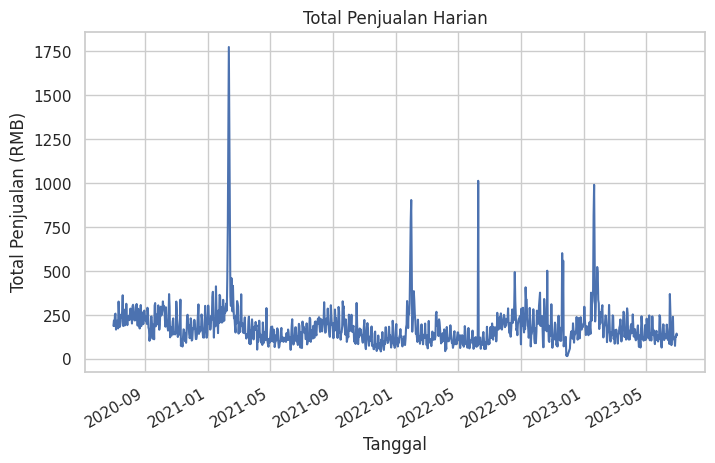

In [36]:
sales_daily.plot(kind="line", title="Total Penjualan Harian", xlabel="Tanggal", ylabel="Total Penjualan (RMB)")
plt.xlabel("Tanggal")
plt.ylabel("Total Penjualan (RMB)")
plt.show()

**Interpretasi** :

Penjualan harian bersifat fluktuatif, dengan beberapa lonjakan, bisa diasumsikan sementara kenaikan terjadi pada hari hari besar atau hari libur panjang

In [37]:
monthly_sales = df_sampel.groupby(df_sampel["Date"].dt.to_period("M"))["Sales"].sum()
monthly_sales.head()

,Sales
Date,
2020-07,7132.4336
2020-08,7621.5336
2020-09,6228.8860
2020-10,6817.2454
2020-11,4813.9254


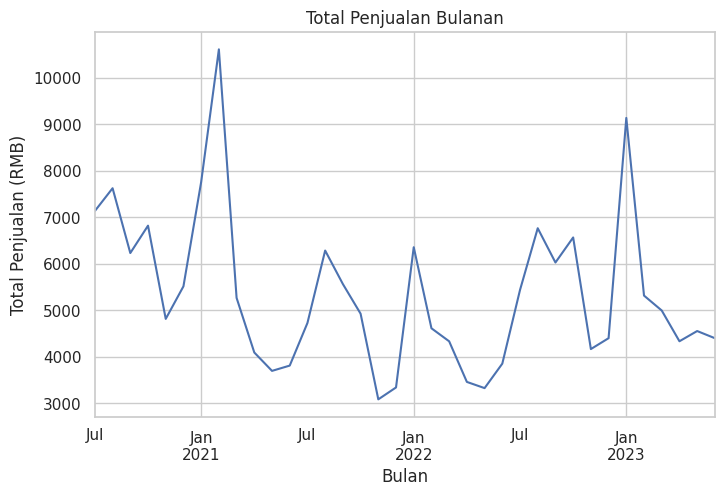

In [38]:
monthly_sales.plot(kind="line", title="Total Penjualan Bulanan", xlabel="Bulan", ylabel="Total Penjualan (RMB)")
plt.xlabel("Bulan")
plt.ylabel("Total Penjualan (RMB)")
plt.show()

Interpretasi:

terjadi lonjakan yang signifikan pada januari tahun 2021 & 2023, dan apabila di perhatikan dengan seksama terjadi lonjakan ini terjadi diakhir tahun dan pertengahan tahun, menandakan penjualan meningkat di musim musim libur panjang setiap tahunnya

### b) 10 produk terlaris berdasarkan kuantitas (bar chart)


Text(0, 0.5, 'Kuantitas Terjual (kg)')

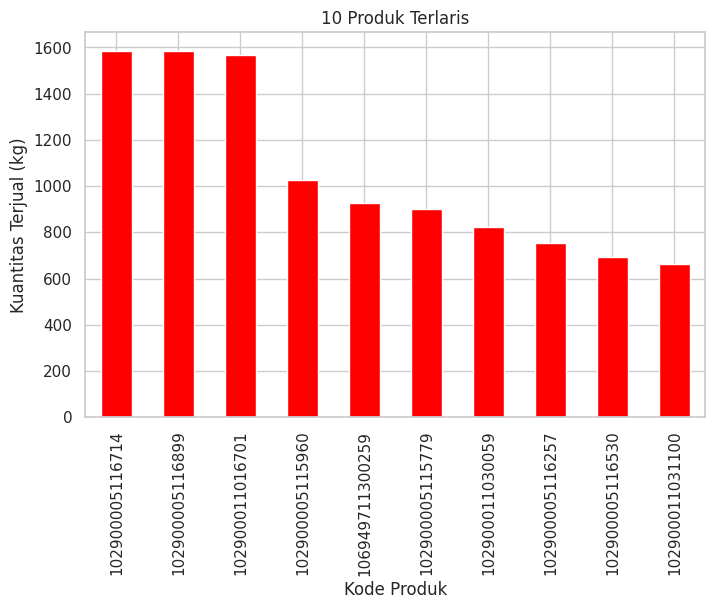

In [50]:
top_10_items = df_sampel.groupby("Item Code")["Quantity Sold (kilo)"].sum().nlargest(10)
top_10_items.head()
top_10_items.plot(kind="bar", title="10 Produk Terlaris", xlabel="Kode Produk", ylabel="Kuantitas Terjual (kg)", color="red")
plt.xlabel("Kode Produk")
plt.ylabel("Kuantitas Terjual (kg)")

**Interpretasi:** Ada sekelompok kecil produk yang mendominasi volume penjualan
(prinsip Pareto/80-20). Produk-produk ini layak diprioritaskan ketersediaan stoknya.

### c) Sebaran harga satuan (boxplot) & pengaruh diskon

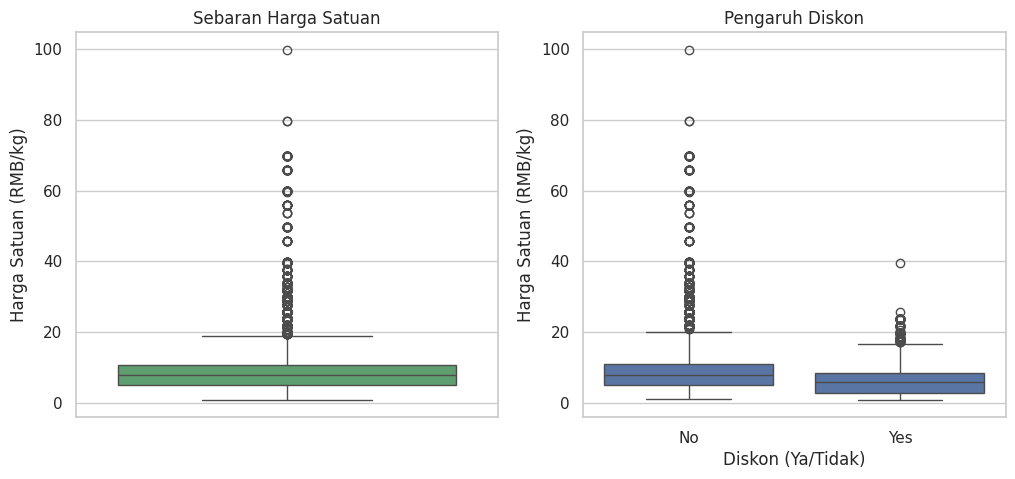

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df_sampel["Unit Selling Price (RMB/kg)"],color="#55A868", ax=axes[0])
axes[0].set_title("Sebaran Harga Satuan")
axes[0].set_ylabel("Harga Satuan (RMB/kg)")


sns.boxplot(x=df_sampel["Discount (Yes/No)"], y=df_sampel["Unit Selling Price (RMB/kg)"],  ax=axes[1])
axes[1].set_title("Pengaruh Diskon")
axes[1].set_xlabel("Diskon (Ya/Tidak)")
axes[1].set_ylabel("Harga Satuan (RMB/kg)")

plt.show()

**Interpretasi:** Mayoritas harga berada di rentang rendah dengan beberapa **outlier** harga tinggi. Produk yang **didiskon** cenderung memiliki sebaran harga yang sedikit berbeda — diskon biasanya diterapkan pada produk tertentu untuk mendorong penjualan.

### d) Kontribusi penjualan: diskon vs tanpa diskon

In [53]:
sales_contribution = df_sampel.groupby("Discount (Yes/No)")["Sales"].sum()
sales_contribution.head()

,Sales
Discount (Yes/No),
No,183847.3508
Yes,9440.5260


/tmp/ipykernel_2031/2027339299.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Total Penjualan Tanpa Diskon:", f"{sales_contribution[0]:,}")
/tmp/ipykernel_2031/2027339299.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Total Penjualan Dengan Diskon:", f"{sales_contribution[1]:,}")


Total Penjualan Tanpa Diskon: 183,847.35080000001
Total Penjualan Dengan Diskon: 9,440.526


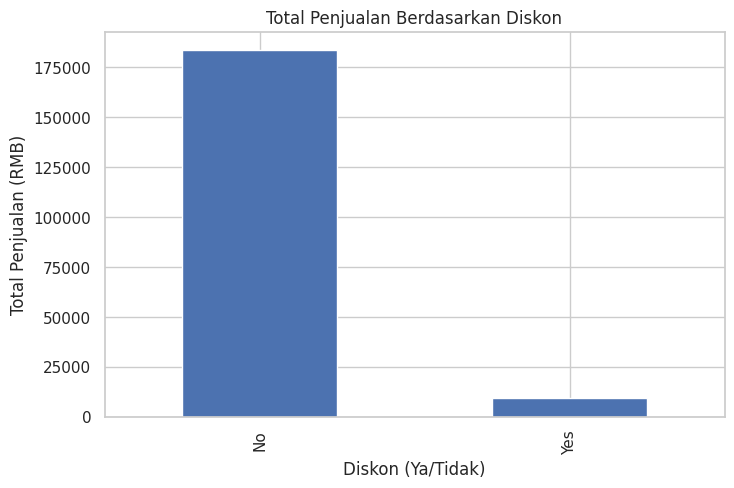

In [60]:
#Visualisasikan
sales_contribution.plot(kind="bar", title="Total Penjualan Berdasarkan Diskon", xlabel="Diskon (Ya/Tidak)", ylabel="Total Penjualan (RMB)")
plt.xlabel("Diskon (Ya/Tidak)")
plt.ylabel("Total Penjualan (RMB)")

print("Total Penjualan Tanpa Diskon:", f"{sales_contribution[0]:,}")
print("Total Penjualan Dengan Diskon:", f"{sales_contribution[1]:,}")

Interpretasi :     
Sebagian besar penjualan berasal dari penjualan non diskon, pengaplikasiannya diskon tidak berpengaruh signifikan terhadap total penjualan.

### e) Mencari waktu tersibuk dalam penjualan (Time)

In [61]:
#ubah waktu dari object jadi tipe data waktu
df_sampel["Time"] = pd.to_datetime(df_sampel["Time"])

#Ambil jam dari waktu
df_sampel["Hour"] = df_sampel["Time"].dt.hour

/tmp/ipykernel_2031/621322116.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sampel["Time"] = pd.to_datetime(df_sampel["Time"])


In [62]:
#Mencari jam tersibuk penjualan
hourly_sales = df_sampel.groupby("Hour")["Sales"].sum()
hourly_sales.head()

,Sales
Hour,
9,17194.4342
10,26787.7536
11,20293.3865
12,11155.3112
13,8256.9899


Text(0, 0.5, 'Total Penjualan (RMB)')

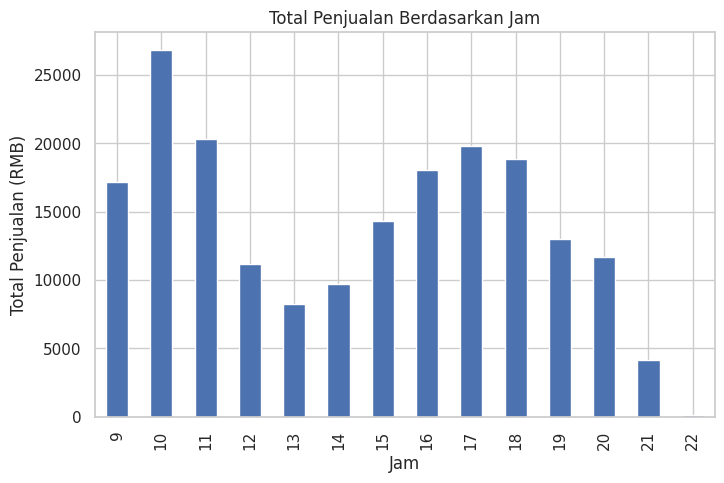

In [63]:
#Visualisasikan waktu tersibuk
hourly_sales.plot(kind="bar", title="Total Penjualan Berdasarkan Jam", xlabel="Jam", ylabel="Total Penjualan (RMB)")
plt.xlabel("Jam")
plt.ylabel("Total Penjualan (RMB)")

Interpretasi :    

Didapati peak hour di jam 10 pagi dimana aktivitas penjualan meningkat signifikan, dan di sore hari pukul 3-5 sore

### F) Menghitung rata rata penjualan per transaksi untuk produk diskon dan non diskon

In [65]:
#Menghitung rata rata per transaksi untuk produk diskon dan non-diskon
average_sales_by_discount = df_sampel.groupby("Discount (Yes/No)")["Sales"].mean()
average_sales_by_discount.head()

,Sales
Discount (Yes/No),
No,3.888069
Yes,3.505580


Text(0, 0.5, 'Rata-rata Penjualan (RMB)')

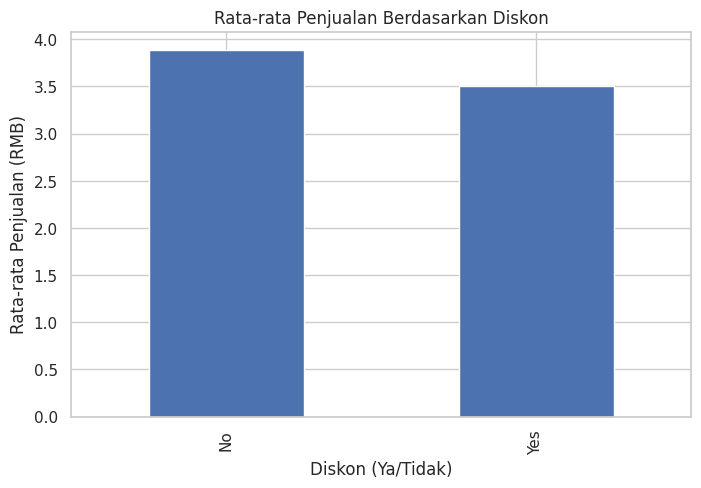

In [66]:
#Visualisasikan
average_sales_by_discount.plot(kind="bar", title="Rata-rata Penjualan Berdasarkan Diskon", xlabel="Diskon (Ya/Tidak)", ylabel="Rata-rata Penjualan (RMB)")
plt.xlabel("Diskon (Ya/Tidak)")
plt.ylabel("Rata-rata Penjualan (RMB)")

Interpretasi :     
penjualan produk kategori non diskon mempunyai rata rata penjualan lebih baik daripada produk dengan kategori diskon

## Kesimpulan & Insight

- Data penjualan supermarket sangat besar (878k+ baris); kita memakai **sampel 50.000** agar efisien.
- Penjualan harian **berfluktuasi** dengan lonjakan periodik → relevan untuk perencanaan stok.
- Penjualan mengikuti pola **Pareto**: sedikit produk menyumbang sebagian besar volume.
- Mayoritas pendapatan dari transaksi **tanpa diskon**; diskon dipakai selektif.
- Keterampilan kunci: konversi tanggal, `resample`, `groupby`, dan sampling untuk data besar.

## 💼 Rekomendasi & Insight Bisnis

Untuk manajer toko, pola penjualan ini langsung dapat ditindaklanjuti: **atur level stok
dan jadwal staf** mengikuti jam/hari puncak, dan **arahkan diskon** ke produk yang perputarannya
lambat — bukan obral menyeluruh. Pola Pareto (sedikit produk = mayoritas volume) menyarankan
fokus pengelolaan pada produk-produk inti tersebut.

### ⚠️ Jebakan Data
- Data 878 ribu baris — **wajib di-sample/agregasi** (kita pakai 50.000) agar laptop tidak kewalahan;
  sebutkan selalu bahwa angka berasal dari sampel.
- Kolom `Sale or Return` memuat **retur** (kuantitas bisa negatif). Bila tidak difilter, total
  penjualan bisa salah hitung — periksa nilai negatif sebelum menjumlahkan.